# Lecture 9: 2D Arrays

Welcome! Today we'll explore **2D arrays** (also called nested lists or lists of lists) and how they can be used to represent and manipulate images. By the end of this lecture, you will be able to:
- understand what 2D arrays are and how to create them
- access and modify elements in 2D arrays using double indexing
- iterate through 2D arrays using nested loops
- apply 2D arrays to image processing tasks

These concepts are essential for HW3 where you'll process images to be converted to knitting patterns!

Before we dive in, one correction about the poll question from Lecture 5:

In [ ]:
x = 5
1 < x < 10 == True # evaluates to False

Not because `==` is evaluated first but simply because this is a contraction of three boolean expressions connected with `and`, and `10 == True` is `False` so the entire expression is `False`:

In [ ]:
1 < x and x < 10 and 10 == True

It was an oversight to think about comparison operators having precedence among themselves but they actually don't have precedence over each other. In some other programming languages they do, but for Python `<`, `>`, `<=`, `>=`, `!=`, `==` are all of equal precedence.

## 2D Array, aka Nested Lists

A **2D array** is essentially **a list of lists**. Recall that we have seen lists of mixed data types, including other lists.

### Why 2D?

A list can already represent a collection of items. But it is usually considered one dimensional. It's like you only have the x axis; without a y axis, you cannot represent a point on a plane. 2D arrays are therefore useful for representing things that are close to a plane, think knitted fabric (it has rows and columns of stitches), images (it has rows and columns of pixels), chess board (8 columns and 8 rows of grid cells), ... Many things that resemble a **grid** require us to organize them into two dimensions!

Think of a 2D function `f(x, y)`, it maps to a single value. We can think of any knitted fabric as such a function but `x` and `y` can only be integers, so this function could output the stitch type of the `x`th row and `y`th column stitch. And we can also think of any image as such a function where `x` and `y` are integeres, and this function outputs the values (e.g., RGBA) at the `x`th row and `y`th column pixel.

Similarly, we can go even further to create 3D arrays, 4D tensors, etc., but we will not go there in this course and will stay within the realm of 2D.

Let's create a simple 2D array representing a 3x4 grid:

In [1]:
# A 3x4 grid (3 rows, 4 columns)
grid = [
    [1, 2, 3, 4],     # row 0
    [5, 6, 7, 8],     # row 1
    [9, 10, 11, 12]   # row 2
]

print(grid)

[[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]]


Let's visualize this grid:

```
     col 0  col 1  col 2  col 3
row 0:  1      2      3      4
row 1:  5      6      7      8
row 2:  9     10     11     12
```

Notice that:
- The outer list has 3 elements (3 rows, each a list)
- Each inner list has 4 elements (4 columns, each a number)

### Dimensions

We can get the dimensions of a 2D array using `len`:

In [2]:
num_rows = len(grid)     # number of rows
num_cols = len(grid[0])  # length of the first row is the number of columns
print(f"Grid is {num_rows} rows x {num_cols} columns")

Grid is 3 rows x 4 columns


### Accessing Elements in 2D Arrays

To access an element, we use **two indices**: `array[row][col]`. Because it's two dimensional!

We have seen this before in one of the polls, and the way to read this operation is to think of the `[]` as an operator that acts on the thing before it using the `index` operand, and read like a usual expression from left to right.

**Understanding double indexing**: for a 2D array, Python will first evaluate `array[row]` to get the list of that row. We can assign `row_list = array[row]` as an intermediate step. Then Python evaluate the second index with `row_list[col]`.

Let's try accessing some elements:

In [3]:
# Access the first row (index 0)
grid[0]

[1, 2, 3, 4]

In [4]:
# Access the element at row 0, column 2
# This is essentially ([1,2,3,4])[2]
grid[0][2]

3

In [5]:
# Access the element at row 1, column 3
grid[1][3]

8

Negative indices work the same way as in lists too.

In [6]:
# Access the last row
grid[-1]

[9, 10, 11, 12]

In [7]:
# Access the last element in the last row
grid[-1][-1]

12

## Modifying Elements in 2D Arrays

Just like regular lists, we can modify elements using assignment:

In [8]:
print("Original grid:")
print(grid)

# Change the element at position (1, 2) to 116
grid[1][2] = 116

print("\nAfter modification:")
print(grid)

Original grid:
[[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]]

After modification:
[[1, 2, 3, 4], [5, 6, 116, 8], [9, 10, 11, 12]]


This grid is not printed as a grid because Python does not automatically knows how to print 2D arrays. We can do it ourselves! To do so, let's first learn about how to iterate over the 2D arrays.

### Iterating Over 2D Arrays: Nested Loops

To process every element in a 2D array, we use a **nested loop** — a loop inside another loop.

The **outer loop** iterates over rows. The **inner loop** iterates over columns within each row.

#### Method 1: Using indices

In [9]:
# Re-define the grid
grid = [
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12]
]

# Get the grid dimensions
num_rows = len(grid)     # number of rows
num_cols = len(grid[0])  # length of the first row

# Nested for loops iterating each row index and column index
for row in range(num_rows):
    for col in range(num_cols):
        print(f"grid[{row}][{col}] = {grid[row][col]}")

grid[0][0] = 1
grid[0][1] = 2
grid[0][2] = 3
grid[0][3] = 4
grid[1][0] = 5
grid[1][1] = 6
grid[1][2] = 7
grid[1][3] = 8
grid[2][0] = 9
grid[2][1] = 10
grid[2][2] = 11
grid[2][3] = 12


Then to print the grid nicely, we can do the following:

In [ ]:
for row in range(num_rows):
    for col in range(num_cols):
        # This prints everything in a single row (end=" ")
        # and format the number to take up at least 3 spaces
        print(f"{grid[row][col]:3d}", end=" ")
    # Print a newline character to start the next row
    print("")

  1   2   3   4 
  5   6   7   8 
  9  10  11  12 


### Method 2: Iterating over values directly

If you don't need the indices, you can iterate directly over the values:

In [11]:
for row in grid:
    for value in row:
        # This prints everything in a single row (end=" ")
        # and format the number to take up at least 3 spaces
        print(f"{value:3d}", end=" ")
    # Print a newline character to start the next row
    print()

  1   2   3   4 
  5   6   7   8 
  9  10  11  12 


Let's just turn this into a function so that we can use this later in the notebook.

In [12]:
def pretty_print(grid):
    """Pretty print a 2D array."""
    for row in grid:
        for value in row:
            print(f"{value:3d}", end=" ")
        print()

We can also turn the index-based iteration into a function and call it `pretty_print_i()`:

In [13]:
def pretty_print_i(grid):
    """Pretty print a 2D array via index-based nested for loops."""
    num_rows = len(grid)     # number of rows
    num_cols = len(grid[0])  # length of the first row
    for row in range(num_rows):
        for col in range(num_cols):
            print(f"{grid[row][col]:3d}", end=" ")
        print()

### Poll Time!

Given the following nested list:
```
ragged = [
    [1, 2, 3],
    [4, 5, 6, 7],
    [8, 9],
    [10]
]
```
What will `pretty_print(ragged)` and `pretty_print_i(ragged)` each print? Think a bit and if you are stuck, discuss with your neighbors or run the cell below!

In [14]:
ragged = [
    [1, 2, 3],
    [4, 5, 6, 7],
    [8, 9],
    [10]
]
print("Result using pretty_print():")
pretty_print(ragged)
print("Result using pretty_print_i():")
pretty_print_i(ragged)

Result using pretty_print():
  1   2   3 
  4   5   6   7 
  8   9 
 10 
Result using pretty_print_i():
  1   2   3 
  4   5   6 
  8   9 

IndexError: list index out of range

<details>
<summary>Explanations here...</summary>

This is a common pitfall with the list with lists of different sizes! We call this ragged lists or ragged arrays, or jagged, awkward arrays.

If we assume the array is a nice rectangle where each sublist has the same number of items, then `pretty_print_i` and `pretty_print` are essentially the same. But when we have ragged arrays, `len(grid[0])` is no longer the number of columns. 

So in our case, the `pretty_print_i` is going to print 1 2 3 on the 1st line, 4 5 6 on the 2nd line, and then 8 9 on the 3rd line before erroring out due to Index Out Of Bounds (it will be trying to access index 2 of the row `[8, 9]` which doesn't exist).

To fix the index-based iteration, we would need to do the following:

```python
def pretty_print_i(grid):
    num_rows = len(grid) # number of rows can stay unchanged
    for row in range(num_rows):
        for col in range(len(grid[row])): # actually use that row's length
            print(f"{grid[row][col]:3d}", end=" ")
        print()
```

**Takeaway**: when using index-based iteration, be careful with potentially ragged arrays!
</details>

### Creating 2D Arrays Programmatically

Often we want to create 2D arrays using code, not by typing out all the values. Let's create a 2D array filled with zeros:

In [15]:
# Create a 5x5 grid of zeros
rows = 5
cols = 5

grid = []
for r in range(rows):
    row = []              # start a new empty row
    for c in range(cols):
        row.append(0)     # add a 0 to this row
    grid.append(row)      # add the completed row to the grid

grid

[[0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0]]

This is again using a nested for loop, just like how we used it to iterate over the 2D array.

#### Practice Time

Let's turn the code from the previous cell into a function that can create a grid of any size! Although we've done this several times, let's just practice more.

Think about the following beforehand:
- what is the function name?
- what are the parameters?
- does the function return anything or just print?
  - if it returns, what are the return values?

In [16]:
# TODO: your function here
def create_zeros_grid(rows, cols):
    """This function creates a grid of zeros of size rows x cols."""
    grid = []
    for r in range(rows):
        row = []              # start a new empty row
        for c in range(cols):
            row.append(0)     # add a 0 to this row
        grid.append(row)      # add the completed row to the grid
    return grid

Then let's call this function with some arguments so that it doesn't create the 5x5 grid again:

In [18]:
# TODO: call your function here
# create_zeros_grid(5, 5)
create_zeros_grid(6, 10)

[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]

We can also use **list comprehension** to make this more concise:

In [19]:
def create_zero_grid_listcomp(rows, cols):
    """Create a 2D array filled with zeros using list comprehension."""
    # This does the same thing as the nested for loop
    return [[0 for c in range(cols)] for r in range(rows)]

# And call the function
zero_grid = create_zero_grid_listcomp(3, 5)
pretty_print(zero_grid)

  0   0   0   0   0 
  0   0   0   0   0 
  0   0   0   0   0 


### Poll Time!

What do you think the resulting `grid` would be? Think a bit before running the cell!

In [ ]:
rows = 3
cols = 4
grid = [[0] * cols] * rows
grid[0][2] = 1
grid[1][2] = -1
pretty_print(grid)

<details>
<summary>Explanations here...</summary>

This is a common pitfall with the * operator! Note how 
```
[[0] * cols] * rows
```
is different from
```
[[0 for c in range(cols)] for r in range(rows)]
```

The latter is list comprehension, and it is actually doing
```
outer_result = []
for r in range(rows):
    inner_result = []
    for c in range(cols):
        inner_result.append(c)
    outer_result.append(inner_result)
```
So each `inner_result` is a new list, and therefore they are different from each other.

However, when using `*`, it repeats the item in the list, and it DOES NOT create a new item, but instead copies the reference to that item. Therefore, each row list is actually the same list. We can use Python Tutor see what is happening:
<iframe width="800" height="300" frameborder="1" src="https://pythontutor.com/iframe-embed.html#code=rows%20%3D%203%0Acols%20%3D%204%0Aarray%20%3D%20%5B%5B0%5D%20*%20cols%5D%20*%20rows&codeDivHeight=400&codeDivWidth=350&cumulative=false&curInstr=0&heapPrimitives=nevernest&origin=opt-frontend.js&py=311&rawInputLstJSON=%5B%5D&textReferences=false"> </iframe>

To make it easier to see, we can add a temporary variable to hold the row list:
<iframe width="800" height="300" frameborder="1" src="https://pythontutor.com/iframe-embed.html#code=rows%20%3D%203%0Acols%20%3D%204%0Arow%20%3D%20%5B0%5D%20*%20cols%0Aarray%20%3D%20%5Brow%5D%20*%20rows&codeDivHeight=400&codeDivWidth=350&cumulative=false&curInstr=0&heapPrimitives=nevernest&origin=opt-frontend.js&py=311&rawInputLstJSON=%5B%5D&textReferences=false"> </iframe>

Because lists are mutable, changing the value in one row list is going to change all the rows because they all point to the same row list.

**Takeaway**: be careful with the `*` operator applied to mutable objects (aka lists)!
</details>

## 2D Arrays and Images

Digital images are perfect examples of 2D arrays! Each pixel in a grayscale image has a brightness value between 0 (black) and 255 (white).

Let's create a simple "image" manually:

In [20]:
# A simple 5x5 "image" (smaller numbers = darker)
image = [
    [0,   0,   0,   0,   0],
    [0, 100, 100, 100,   0],
    [0, 100, 255, 100,   0],
    [0, 100, 100, 100,   0],
    [0,   0,   0,   0,   0]
]

And we can define a function that pretty print it with visual symbols (yes, Python strings can contain characters that are not a to z, including emojis!):

In [ ]:
def pretty_print_symbol(image):
    # Print it in a more visual way
    for row in image:
        for pixel in row:
            if pixel == 0:
                print("█", end="")  # black
            elif pixel < 150:
                print("▓", end="")  # dark gray
            else: # pixel >= 150
                print("░", end="")  # light gray
        print()

In [22]:
pretty_print_symbol(image)

█████
█▓▓▓█
█▓░▓█
█▓▓▓█
█████


Python of course has libraries that can display images:

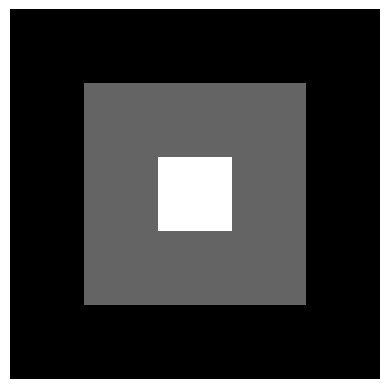

In [23]:
from matplotlib import pyplot as plt

def show_image(image):
    plt.imshow(image, cmap="gray")
    plt.axis("off")

show_image(image)

### Image Processing

There are many different kinds of image processing tasks. Most of them involve editing the pixel values of an image. 

**Thresholding** is a common image processing technique where we threshold 

Rule: If a pixel value is above the threshold, set it to 1 (white), otherwise set it to 0 (black).

In [24]:
def threshold_image(image, threshold):
    """
    Convert a grayscale image to binary based on a threshold.
    
    Parameters:
        image: 2D list of integers (pixel values)
        threshold: cutoff value (0-255)
    
    Returns:
        2D list of 0s and 1s
    """
    result = []
    
    for row in image:
        new_row = []
        for pixel in row:
            if pixel <= threshold:
                new_row.append(0)
            else:
                new_row.append(1)
            # new_row.append(0 if pixel <= threshold else 1)
        result.append(new_row)
    
    return result


Thresholded image (threshold=50):


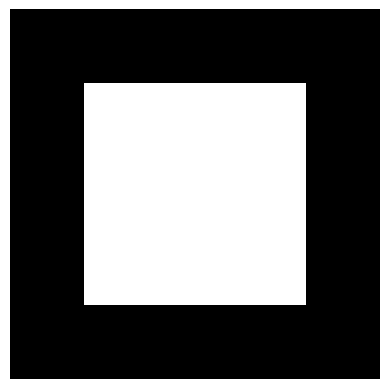

In [25]:
# Apply threshold at 50
binary_image = threshold_image(image, 50)
print("\nThresholded image (threshold=50):")
show_image(binary_image)

## Practice Exercise 1: Invert an Image

Write a function that inverts an image by subtracting each pixel from 255.

For example:
- 0 (black) becomes 255 (white)
- 255 (white) becomes 0 (black)
- 100 becomes 155

In [ ]:
def invert_image(image):
    """
    Invert an image (negative).
    
    Parameters:
        image: 2D list of pixel values
    
    Returns:
        2D list with inverted pixel values
    """
    # TODO: implement this function
    pass

In [ ]:
# Test it
inverted = invert_image(image)
print("\nInverted:")
show_image(inverted)

## Practice Exercise 2: Add two 2D arrays

What if you have two 2D arrays and you want to add them, just like adding to matrices? Implement a function that add two matrices element-wise.

In [ ]:
def add_2d_arrays(arr1, arr2):
    """
    Element-wise addition for 2D arrays.
    
    Parameters:
        arr1: the first 2D array
        arr2: the second 2D array
    
    Returns:
        a 2D array which is the sum of the input arrays
    """
    # TODO: implement this function
    pass

In [ ]:
# Test it
arr1 = [
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
]
arr2 = [
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
]
sum_arr = add_2d_arrays(arr1, arr2)
pretty_print(sum_arr)

## Summary

Today we learned:
- **2D arrays** are lists of lists, accessed with `grid[row][col]`
- **Nested loops** let us iterate over all elements in a 2D array
- **Common pitfalls** including creating shared row references with `[row] * n` and ragged nested lists
- **Pixel images** are naturally represented as 2D binary arrays

If time remains, we will start going over more about how we actually write knitout code, and next lecture, we will discuss some basic colorwork techniques which will prepare you for HW3. But with today's lecture, you can already start on HW3 Part 1 that's about strings, files, and 2D arrays!